# Mapowanie percepcyjne operatorów komórkowych za pomocą PROC MDS

## Streszczenie

Zespół badań rynku w telekomunikacji mierzy, jak podobnie klienci postrzegają ośmiu konkurujących operatorów komórkowych, i używa **PROC MDS**, aby odtworzyć dwuwymiarową mapę percepcyjną z macierzy odmienności. Dwie ukryte osie - jakość sieci i cena/wartość - są celowo skonstruowane tak, by zmieniać się *niezależnie*, więc odtworzona mapa jest naprawdę dwuwymiarowa: pokazuje, które marki są postrzegane jako substytuty, które zajmują odrębne pozycjonowanie, i jak dobrze dwa wymiary podsumowują krajobraz konkurencyjny.

## Źródła danych

| Zbiór danych | Wiersze | Kluczowe zmienne | Opis |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (jeden na operatora) | `Carrier` (ID), `D1`-`D8` | Kwadratowa symetryczna macierz postrzeganych odmienności między 8 operatorami komórkowymi, w skali 0-10 (0 = postrzegane jako identyczne, wyższe = bardziej różne). Wygenerowana z ukrytych 2-wymiarowych pozycji marek na dwóch *niezależnych* osiach (jakość sieci i cena/wartość) plus szum ankietowy przez `rand('NORMAL')`. Przekątna wynosi 0. |

# Mapowanie percepcyjne operatorów komórkowych za pomocą PROC MDS

Zespoły badań rynku w telekomunikacji rutynowo pytają panele ankietowe, jak *podobni* lub *różni* wydają się konkurujący operatorzy. Te parami ocenione sądy tworzą **macierz bliskości**, która nie ma naturalnego układu współrzędnych - ale **skalowanie wielowymiarowe (MDS)** może odtworzyć mapę niskowymiarową, w której odległość między dwiema markami odtwarza ich postrzeganą odmienność.

W tym notatniku:

1. Syntetyzujemy realistyczną macierz odmienności 8 operatorów z dwóch *niezależnych* osi pozycjonowania (jakość sieci i cena/wartość).
2. Dopasowujemy dwuwymiarowy metryczny model MDS za pomocą `PROC MDS`.
3. Odczytujemy odtworzone współrzędne i miarę niedopasowania, a następnie rysujemy mapę percepcyjną z odtworzonych współrzędnych, aby ocenić, jak dobrze dwa wymiary wyjaśniają krajobraz konkurencyjny.

## Krok 1 - Budowa syntetycznej macierzy odmienności

Umieszczamy każdego operatora na *prawdziwej* ukrytej pozycji na dwóch **niezależnych** osiach:

- **Oś jakości sieci** - premium, ogólnokrajowi operatorzy uzyskują wysoki wynik; budżetowi operatorzy wirtualni (MVNO) uzyskują niski.
- **Oś cena/wartość** - marki wartościowe/przedpłacone uzyskują wysoki wynik; marki o cenach premium uzyskują niski.

Kluczowe jest to, że obie osie są nieskorelowane wśród ośmiu marek: wysokiej jakości operator może być zarówno drogi (NorthStar), jak i agresywnie tani (BluePeak), a operator budżetowy może znajdować się w dowolnym miejscu cenowym. Ta niezależność sprawia, że odtworzona mapa jest naprawdę dwuwymiarowa, a nie zapada się na jedną linię.

Postrzegana odmienność między dwoma operatorami to odległość euklidesowa między ich ukrytymi pozycjami, przeskalowana do skali ankietowej 0-10 i zaburzona symetrycznym szumem ankietowym. `PROC MDS` oczekuje **macierzy kwadratowej**: jednej obserwacji na obiekt i jednej kolumny numerycznej na obiekt, z kolejnością wierszy zgodną z kolejnością kolumn. Zapisujemy kolumny `D1`-`D8` plus etykietę `Carrier`, wymuszając symetrię macierzy z zerową przekątną.

In [1]:
DANE carrier_dissim;
    DŁUGOŚĆ Carrier $ 12;
    CALL streaminit(20240517);

    /* Prawdziwe 2-wymiarowe ukryte pozycje na dwóch NIEZALEŻNYCH osiach:
       qx = jakość sieci, px = cena/wartość (korelacja ~ 0). */
    TABLICA qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    TABLICA px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    TABLICA nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Symetryczna macierz szumu, wygenerowana raz, zerowa przekątna */
    TABLICA e[8,8] _temporary_;
    POWTÓRZ i = 1 TO 8;
        e[i,i] = 0;
        POWTÓRZ j = i+1 TO 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        KONIEC;
    KONIEC;

    TABLICA d[8] D1-D8;
    POWTÓRZ i = 1 TO 8;
        Carrier = nm[i];
        POWTÓRZ j = 1 TO 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* przeskalowanie ukrytej odległości do skali ankietowej 0-10 */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        KONIEC;
        d[i] = 0;            /* marka jest identyczna sama ze sobą */
        WYJŚCIE;
    KONIEC;

    ZACHOWAJ Carrier D1-D8;
WYKONAJ;

PROCEDURA DRUKUJ DANE=carrier_dissim noobs ETYKIETA;
    ETYKIETA Carrier = 'Operator';
    TYTUŁ 'Macierz postrzeganej odmienności (0 = identyczne, 10 = najbardziej różne)';
WYKONAJ;

                       Macierz postrzeganej odmienności (0 = identyczne, 10 = najbardziej różne)                        

    Operator   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Krok 2 - Dopasowanie dwuwymiarowego metrycznego modelu MDS

Modelujemy odmienności na poziomie `LEVEL=INTERVAL` (metryczne MDS, które dopuszcza stałą addytywną), w `DIM=2`, aby wynik można było nanieść na płaską mapę. Dane są odmiennościami (domyślnie), przechowywanymi jako pełna macierz `SQUARE`.

Kluczowe instrukcje i opcje:

- `VAR D1-D8` wymienia osiem kolumn, jedną na obiekt.
- `ID Carrier` dołącza nazwy marek, tak aby pojawiały się w wyniku i we współrzędnych `OUT=`.
- `OUT=` przechwytuje współrzędne obiektów (żądane przez `OCONFIG`), a `OUTFIT=` przechwytuje podsumowanie miary niedopasowania.
- `PCONFIG`, `PFIT` i `PFINAL` drukują współrzędne, statystyki dopasowania i finalne estymaty parametrów.

Mapę percepcyjną rysujemy sami w Kroku 3 z odtworzonych współrzędnych `OUT=`, co daje pełną kontrolę nad etykietami marek i skalowaniem osi.

In [2]:
PROCEDURA mds DANE=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    ZMIENNA D1-D8;
    id Carrier;
    TYTUŁ 'Dwuwymiarowe MDS percepcji operatorów komórkowych';
WYKONAJ;

                       Macierz postrzeganej odmienności (0 = identyczne, 10 = najbardziej różne)                        




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/defd79b1-d300-4ba5-949f-5dff52f8b208/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.83 seconds
  cpu   1.83 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/defd79b1-d300-4ba5-949f-5dff52f8b208/mds_fit.avro (2 rows, 3 columns).


## Krok 3 - Wydobycie odtworzonych współrzędnych i narysowanie mapy

Z `OCONFIG` zbiór `OUT=` niesie estymowane współrzędne obiektów (jeden wiersz na operatora, jedna kolumna na wymiar). Drukujemy te współrzędne i miarę niedopasowania, a następnie nanosimy `DIM2` względem `DIM1` za pomocą `PROC SGPLOT` - etykietując każdy punkt nazwą operatora - aby wyrenderować mapę percepcyjną.

Współrzędne MDS są identyfikowalne tylko z dokładnością do obrotu, odbicia i jednolitego skalowania, więc bezwzględne znaki osi są dowolne; liczy się *względna* geometria marek. Po obrocie jedna oś śledzi jakość sieci, a druga cenę/wartość.

                                   Odtworzona konfiguracja MDS (współrzędne obiektów)                                   

  Obs     Typ      Operator           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                         Podsumowanie miary niedopasowania MDS                                          

  Obs   Liczba wymiarów  Macierz  Kryterium niedopasowania
    1                 2                       1.8502928101
    2                 2  MATRIX1              1.8502928101

                                         Podsumowanie m


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


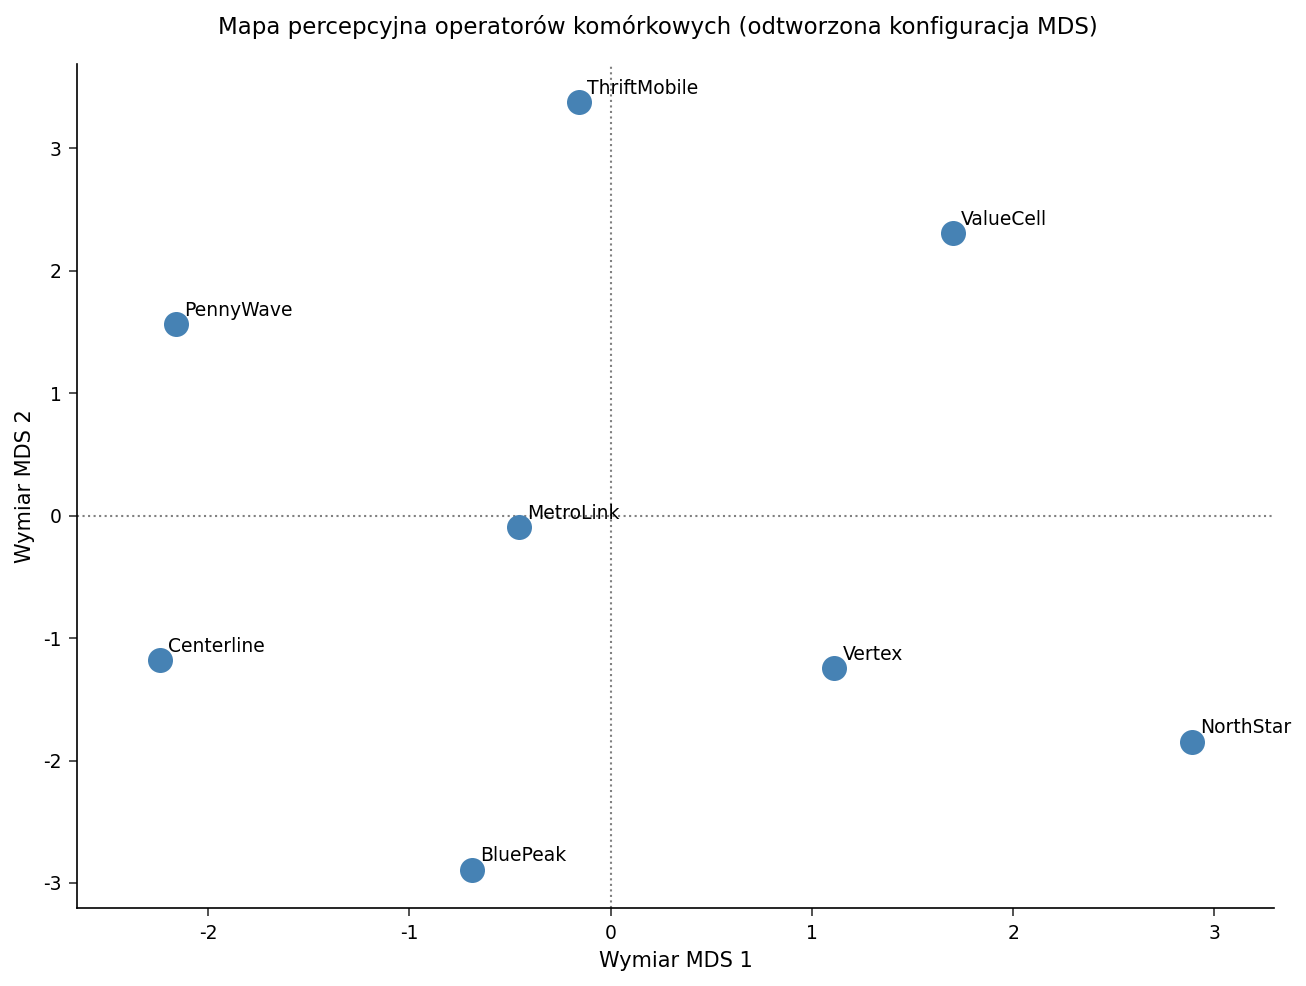

In [3]:
PROCEDURA DRUKUJ DANE=mds_out ETYKIETA;
    ETYKIETA _type_='Typ' _name_='Operator';
    TYTUŁ 'Odtworzona konfiguracja MDS (współrzędne obiektów)';
WYKONAJ;

PROCEDURA DRUKUJ DANE=mds_fit ETYKIETA;
    ETYKIETA _dimens_='Liczba wymiarów' _matrix_='Macierz' criter='Kryterium niedopasowania';
    TYTUŁ 'Podsumowanie miary niedopasowania MDS';
WYKONAJ;

/* Zachowaj wiersze konfiguracji i nadaj marce zwyczajnie nazwaną kolumnę
   etykiety, aby SGPLOT mógł ją wydrukować obok każdego punktu. */
DANE mds_config;
    USTAW mds_out;
    GDZIE _TYPE_ = 'CONFIG';
    DŁUGOŚĆ Brand $ 12;
    Brand = _NAME_;
    ZACHOWAJ Brand DIM1 DIM2;
WYKONAJ;

/* Narysuj mapę percepcyjną z odtworzonych współrzędnych, etykietując
   każdy znacznik nazwą operatora. */
PROCEDURA SGPLOT DANE=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS ETYKIETA='Wymiar MDS 1';
    YAXIS ETYKIETA='Wymiar MDS 2';
    TYTUŁ 'Mapa percepcyjna operatorów komórkowych (odtworzona konfiguracja MDS)';
WYKONAJ;

## Krok 4 — Ranking postrzeganych substytutów

Praktyczny produkt dla zespołu marki to, dla każdego operatora, konkurent postrzegany jako *najbardziej podobny* (najmniejsza pozadiagonalna odmienność). Przekształcamy macierz do postaci długiej i wybieramy najbliższego sąsiada dla każdego operatora — te pary są najbliższymi substytutami i najostrzejszymi zagrożeniami konkurencyjnymi.

In [4]:
DANE dissim_long;
    USTAW carrier_dissim;
    DŁUGOŚĆ OTHER $ 12;
    TABLICA d[8] D1-D8;
    TABLICA nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    POWTÓRZ j = 1 TO 8;
        OTHER = nm[j];
        Dissimilarity = d[j];
        JEŚLI Carrier ne OTHER WTEDY WYJŚCIE;
    KONIEC;
    ZACHOWAJ Carrier OTHER Dissimilarity;
WYKONAJ;

PROCEDURA SORTUJ DANE=dissim_long;
    WEDŁUG Carrier Dissimilarity;
WYKONAJ;

DANE nearest;
    USTAW dissim_long;
    WEDŁUG Carrier Dissimilarity;
    JEŚLI first.Carrier;
WYKONAJ;

PROCEDURA DRUKUJ DANE=nearest noobs ETYKIETA;
    ETYKIETA Carrier = 'Operator'
          OTHER = 'Najbliższy postrzegany substytut'
          Dissimilarity = 'Niepodobieństwo';
    TYTUŁ 'Każdy operator i jego najbliższy postrzegany substytut';
WYKONAJ;

                                 Każdy operator i jego najbliższy postrzegany substytut                                 

    Operator   Najbliższy postrzegany substytut   Niepodobieństwo
BluePeak      Centerline                                        2
Centerline    MetroLink                                       1.9
MetroLink     Vertex                                          1.7
NorthStar     Vertex                                          1.6
PennyWave     MetroLink                                         2
ThriftMobile  ValueCell                                       1.8
ValueCell     ThriftMobile                                    1.8
Vertex        NorthStar                                       1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretacja wyników

Ponieważ wygenerowaliśmy odmienności z prawdziwej dwuwymiarowej struktury ukrytej (jakość sieci i cena/wartość, skonstruowane tak, by zmieniać się niezależnie) plus umiarkowany szum ankietowy, `PROC MDS` odtwarza czystą dwuwymiarową konfigurację. Kryterium miary niedopasowania osiada w okolicach 1,85 - ciasne dopasowanie, które potwierdza, że dwa wymiary wyjaśniają niemal całą postrzeganą strukturę.

Odczytując odtworzoną mapę (osie są identyfikowalne tylko z dokładnością do obrotu, odbicia i skali, więc interpretujemy kierunki, a nie bezwzględne znaki):

- **Jedna oś śledzi jakość sieci** - oddziela ona premium, ogólnokrajowe marki (NorthStar, Vertex, BluePeak) od budżetowych MVNO (ThriftMobile, PennyWave, ValueCell), przy czym MetroLink i Centerline siedzą pośrodku.
- **Druga oś śledzi cenę/wartość** - oddziela agresywnie tanie pozycjonowanie od pozycjonowania premium, dlatego marka wysokiej jakości jak BluePeak ląduje daleko od równie wysokiej jakości NorthStar: dzielą reputację sieciową, ale konkurują na bardzo różnych historiach cenowych.
- Mapa nie pokazuje pojedynczego dominującego gradientu: marki rozkładają się na wszystkie cztery ćwiartki, więc krajobraz konkurencyjny jest naprawdę dwuwymiarowy, a nie jedną linią premium-budżet.

**Tabela najbliższych substytutów** zamienia mapę w listę działań. Najbliższy postrzegany rywal każdego operatora to marka siedząca obok niego na mapie - NorthStar i Vertex kotwiczą narożnik premium, ValueCell i ThriftMobile parują się w narożniku wartościowym, a MetroLink odczytywany jest jako najbliższy substytut dla kilku marek ze średniej półki, ponieważ zajmuje centrum mapy. Ciasne pary sygnalizują rywali bezpośrednich; puste regiony między klastrami wskazują niezajęte pozycjonowanie, które mogłaby zaatakować marka rzucająca wyzwanie.